### Hierarchial clustering of AF complexes

In [22]:
import mdtraj as md
import numpy as np
import glob
import os
from scipy.cluster.hierarchy import fcluster, linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

In [49]:
models_dir = "./2WT" # the directory for models, should be specified
reference_pdb = None # then 1 structure will be the reference
chainA_selection = "chainid 0 and name CA"
chainB_selection = "chainid 1 and name CA"
rmsd_cutoff = 0.5 # 3 angstroms

In [50]:
pdb_files = sorted(glob.glob(os.path.join(models_dir, "*.pdb")))
models = [md.load(f) for f in pdb_files]

In [51]:
top0 = models[0]
chainA_CA = top0.topology.select(chainA_selection)
chainB_CA = top0.topology.select(chainB_selection)

In [52]:
coords_list = []
for i, traj in enumerate(models):
    if i == 0:
        ref_coords = models[0].xyz[0, chainA_CA, :] # shape (n_atoms, 3)
    traj.superpose(models[0], atom_indices=chainA_CA)
    coords_list.append(traj.xyz[0, chainB_CA, :])

coord_all = np.stack(coords_list)

In [53]:
n_models = len(models)
rmsd_matrix = np.zeros((n_models, n_models))
for i in range(n_models):
    for j in range(i+1, n_models):
        diff = coord_all[i] - coord_all[j]
        rmsd = np.sqrt(np.mean(np.sum(diff**2, axis=1)))
        rmsd_matrix[i, j] = rmsd
        rmsd_matrix[j, i] = rmsd

dist_vec = squareform(rmsd_matrix) # convert for scipy

In [54]:
linkage_matrix = linkage(dist_vec, method="average")
clusters = fcluster(linkage_matrix, t=rmsd_cutoff, criterion="distance")
len(set(clusters))

67

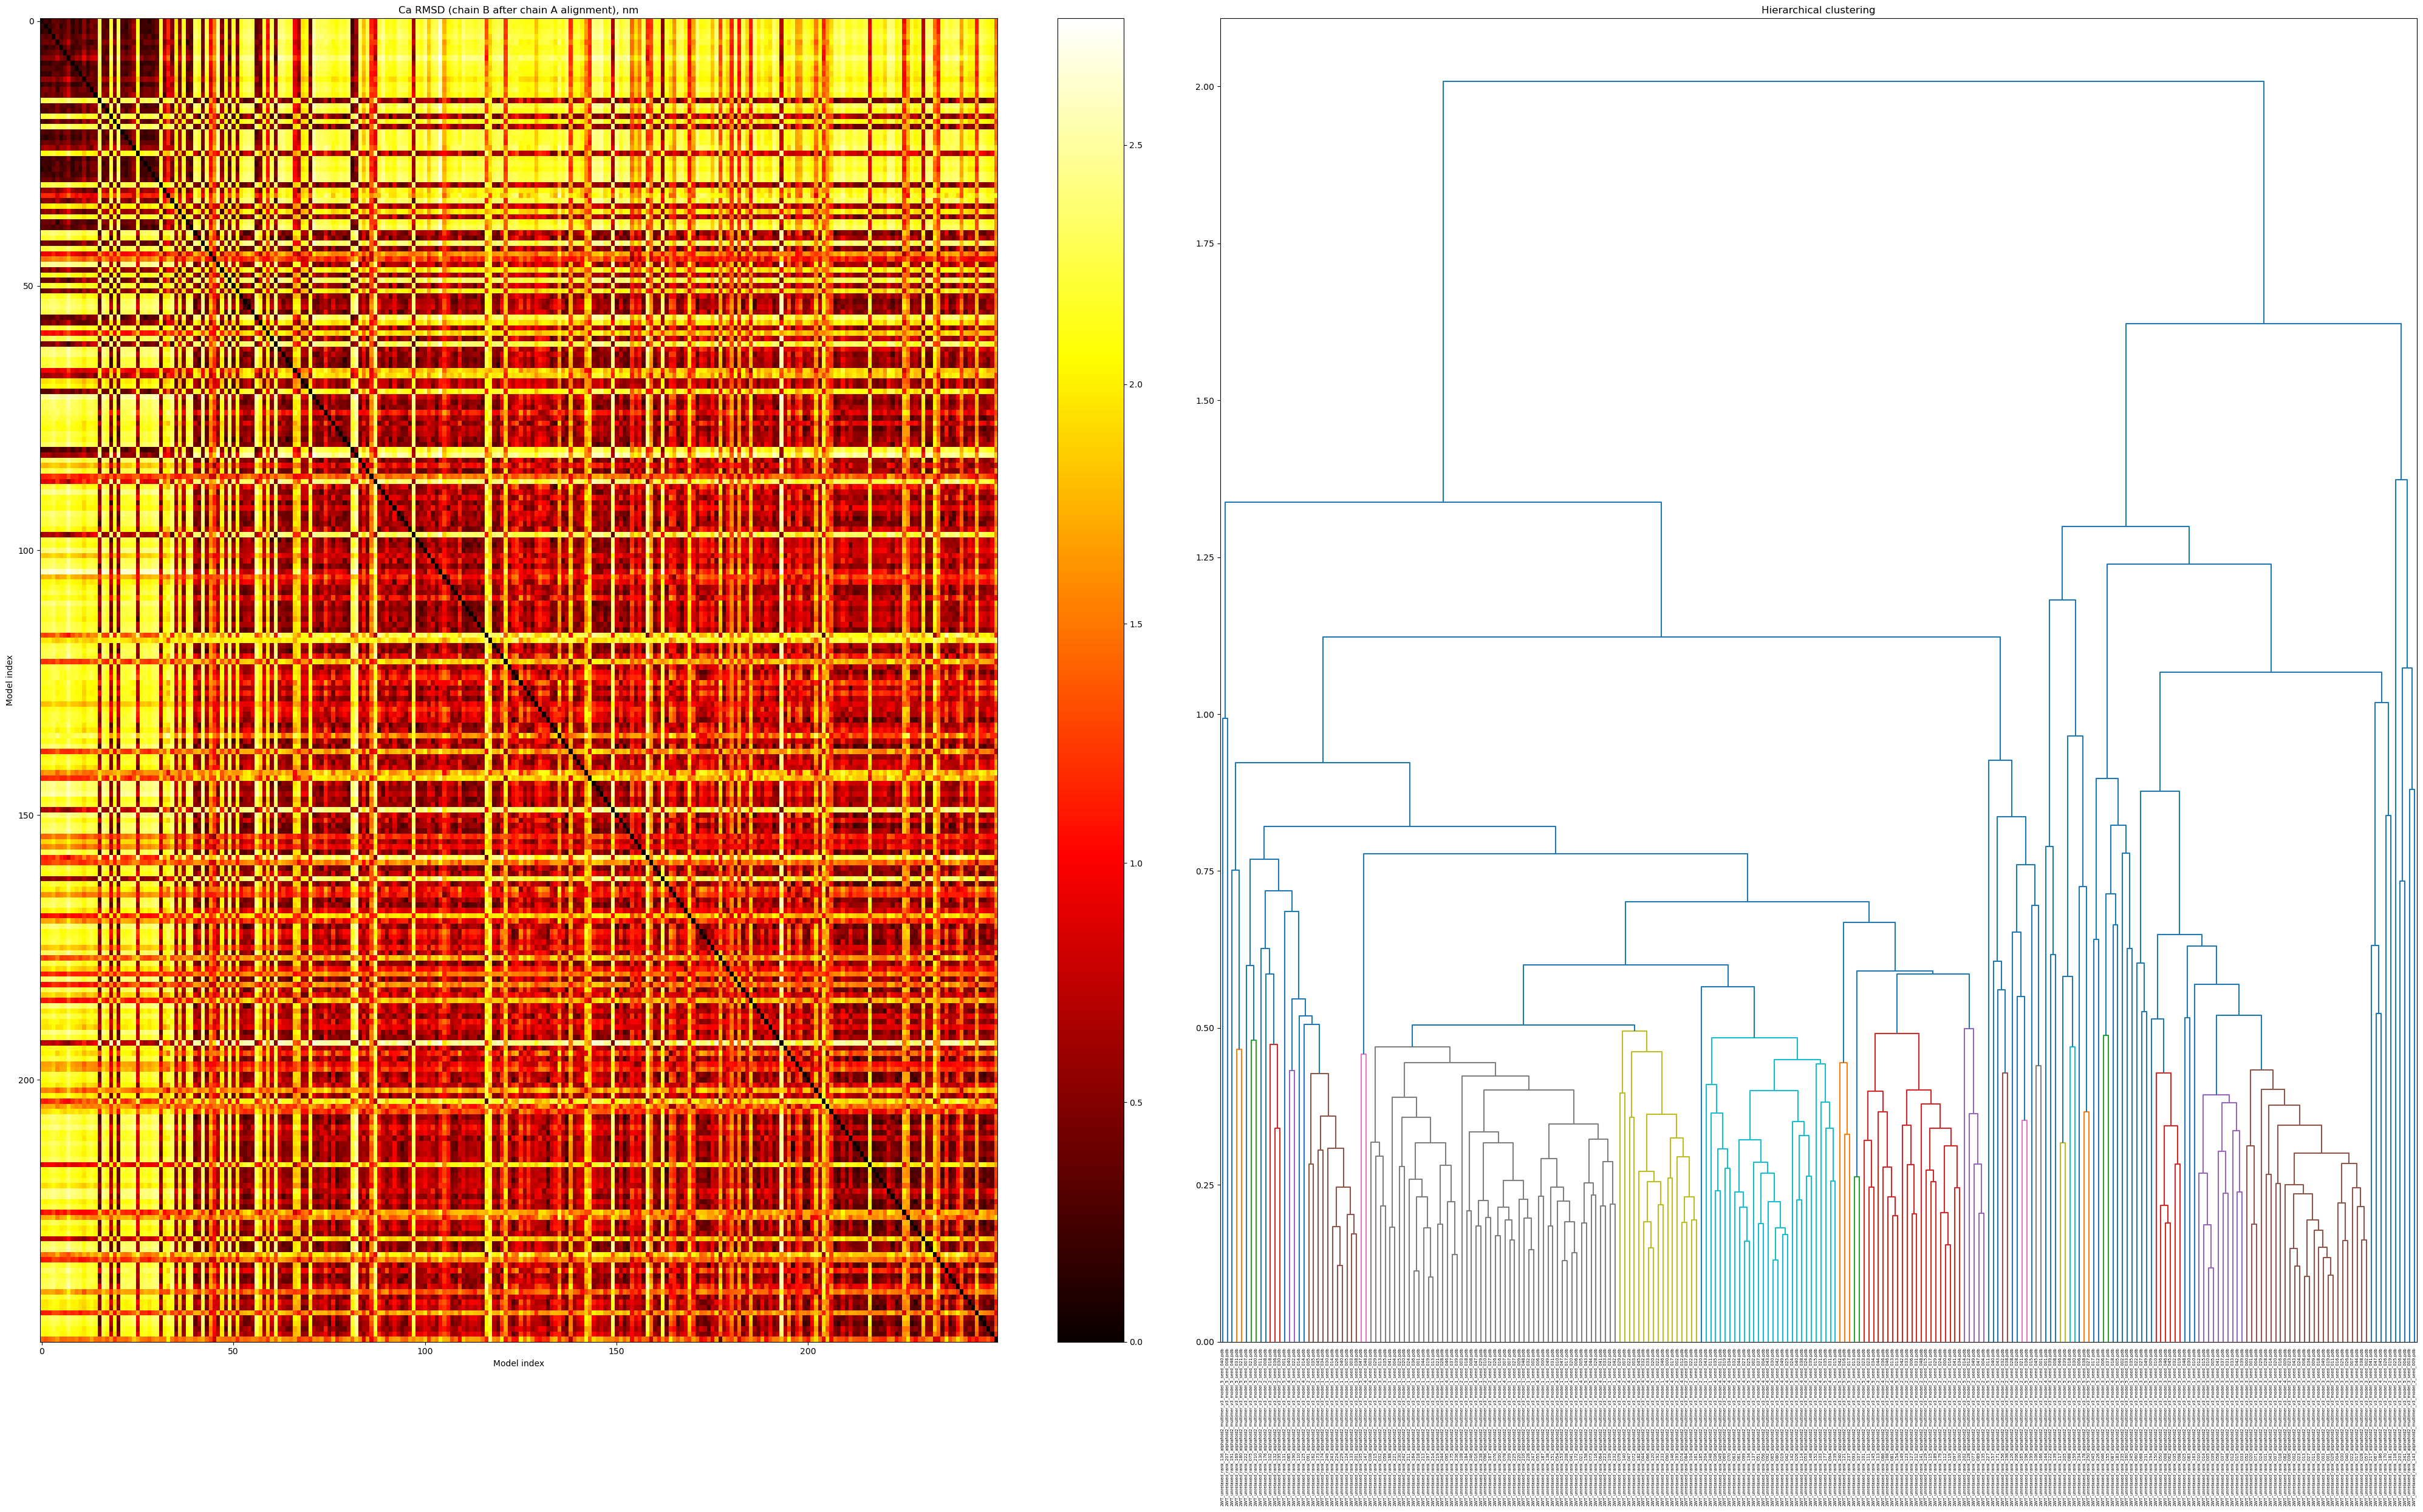

In [55]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(40, 25))

im = ax1.imshow(rmsd_matrix, cmap="hot", aspect='auto')
ax1.set_title("Ca RMSD (chain B after chain A alignment), nm")
ax1.set_xlabel("Model index")
ax1.set_ylabel("Model index")
plt.colorbar(im, ax=ax1)


dendrogram(linkage_matrix, ax=ax2, color_threshold=rmsd_cutoff, labels=[os.path.basename(f) for f in pdb_files])
ax2.set_title(f"Hierarchical clustering")
ax2.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

### DBSCAN

In [56]:
from sklearn.cluster import DBSCAN
eps_nm = 0.5 # neighboring radius for rmsd clustering
min_samples = 2 # minimum points to form a cluster

# forming distance matrix for DBSCAN
clustering = DBSCAN(eps=eps_nm, min_samples=min_samples, metric="precomputed")
db_labels = clustering.fit_predict(rmsd_matrix)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = np.sum(db_labels == -1)

In [57]:
print(n_clusters)
print(n_noise)

7
32


In [58]:
from collections import defaultdict
clusters_indices = defaultdict(list)
for idx, label in enumerate(db_labels):
    clusters_indices[label].append(idx)

In [59]:
for label, idx_list in clusters_indices.items():
    if label == -1:
        continue
    if len(idx_list) == 1:
        rep_idx = idx_list[0]
    else:
        sub = rmsd_matrix[np.ix_(idx_list, idx_list)]
        mean_rmsd = np.mean(sub, axis=1)
        rep_idx = idx_list[np.argmin(mean_rmsd)]
    out_name = f"dbscan_cluster_{label}_rep.pdb"
    models[rep_idx].save(out_name)
    print(f"Cluster with {label} had {len(idx_list)} models, saved as {out_name}")

Cluster with 0 had 48 models, saved as dbscan_cluster_0_rep.pdb
Cluster with 1 had 158 models, saved as dbscan_cluster_1_rep.pdb
Cluster with 2 had 2 models, saved as dbscan_cluster_2_rep.pdb
Cluster with 3 had 4 models, saved as dbscan_cluster_3_rep.pdb
Cluster with 4 had 2 models, saved as dbscan_cluster_4_rep.pdb
Cluster with 5 had 2 models, saved as dbscan_cluster_5_rep.pdb
Cluster with 6 had 2 models, saved as dbscan_cluster_6_rep.pdb


### DSSP calculations for DBSCAN

In [ ]:
import os
import glob
import mdtraj as md
import numpy as np


rep_dir = "."
min_strand_length = 3
rep_files = sorted(glob.glob(os.path.join(rep_dir, "dbscan_cluster_*_rep.pdb")))


candidates = []

for rep_file in rep_files:
    traj = md.load(rep_file)
    top = traj.topology
    chains = list(top.chains)
    ss = md.compute_dssp(traj, simplified=False)[0]
    print(ss)
    
    # if len(chains) < 2:
    #     continue
    # chainA = chains[0]
    # chainB = chains[1]

    # resA = [r.index for r in chainA.residues]
    # resB = [r.index for r in chainB.residues]

### iRMSD

In [2]:
import os
import glob
import numpy as np
import mdtraj as md
from scipy.cluster.hierarchy import fcluster, linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import defaultdict

models_dir = "./2WT" # the directory for models, should be specified
chainA_id = 0
chainB_id = 1
rmsd_cutoff = 0.3 # 3 angstroms
interface_cutoff = 0.8 # 


def get_interface_residues(traj, chainA_idx, chainB_idx, cutoff=interface_cutoff):
    top = traj.topology
    heavyA = top.select(f"chainid {chainA_idx} and not element H")
    heavyB = top.select(f"chainid {chainB_idx} and not element H")
    xyz = traj.xyz[0]
    dists = np.linalg.norm(xyz[heavyA][:, None, :] - xyz[heavyB][None, :, :], axis=2)
    close_pairs = np.where(dists < cutoff)

    if len(heavyA) == 0 or len(heavyB) == 0:
        return set(), set()
    resA = set()
    resB = set()
    for i, j in zip(close_pairs[0], close_pairs[1]):
        resA.add(top.atom(heavyA[i]).residue.index)
        resB.add(top.atom(heavyB[j]).residue.index)
    if len(close_pairs[0]) == 0:
        return np.array([], dtype=int), np.array([], dtype=int)
    else:
        return resA, resB

def build_ca_index_map(traj):
    ca_map = {}
    top = traj.topology
    for atom in top.atoms:
        if atom.name == "CA":
            res = atom.residue
            ca_map[(res.chain.index, res.index)] = atom.index
    return ca_map


def get_ca_indices_for_residues(ca_map, chain_idx, res_set):
    indices = []
    for r in sorted(res_set):
        key = (chain_idx, r)
        if key in ca_map:
            indices.append(ca_map[key])
    return np.array(indices, dtype=int)

In [3]:
pdb_files = sorted(glob.glob(os.path.join(models_dir, "*.pdb")))
models = [md.load(f) for f in pdb_files]
n_models = len(models)


interface_data = []
for i, traj in enumerate(tqdm(models, desc="Precomputing interfaces")):
    resA, resB = get_interface_residues(models[i], chainA_id, chainB_id, interface_cutoff)
    ca_map = build_ca_index_map(traj)
    interface_data.append((resA, resB, ca_map))


irmsd_matrix = np.zeros((n_models, n_models))
for i in tqdm(range(n_models)):
    resA_i, resB_i, ca_map_i = interface_data[i]
    for j in range(i+1, n_models):
        resA_j, resB_j, ca_map_j = interface_data[j]   
        commonA = resA_i & resA_j
        commonB = resB_i & resB_j

        caA_i = get_ca_indices_for_residues(ca_map_i, chainA_id, commonA)
        caB_i = get_ca_indices_for_residues(ca_map_i, chainB_id, commonB)
        caA_j = get_ca_indices_for_residues(ca_map_j, chainA_id, commonA)
        caB_j = get_ca_indices_for_residues(ca_map_j, chainB_id, commonB)

        if not (len(caA_i) == len(caA_j) == len(caB_i) == len(caB_j)):
            irmsd_matrix[i, j] = 999.0
            irmsd_matrix[j, i] = 999.0
            continue
        
        interface_i = np.concatenate([caA_i, caB_i])
        interface_j = np.concatenate([caA_j, caB_j])
        
        models[j].superpose(models[i], atom_indices=interface_j, ref_atom_indices=interface_i)
        diff = models[j].xyz[0, interface_j, :] - models[i].xyz[0, interface_i, :]
        rmsd_val = np.sqrt(np.mean(np.sum(diff**2, axis=1)))
        irmsd_matrix[i, j] = rmsd_val
        irmsd_matrix[j, i] = rmsd_val
np.fill_diagonal(irmsd_matrix, 0)

valid_mask = np.array([len(data[0]) > 0 and len(data[1]) > 0 for data in interface_data])
if not np.any(valid_mask):
    raise RuntimeError("No models with an interface")

valid_indices = np.where(valid_mask)[0]
rmsd_sub = irmsd_matrix[np.ix_(valid_indices, valid_indices)]
dist_vec = squareform(rmsd_sub)
linkage_matrix = linkage(dist_vec, method='average')
clusters_sub = fcluster(linkage_matrix, t=rmsd_cutoff, criterion='distance')


clusters_full = -1 * np.ones(n_models, dtype=int)
clusters_full[valid_indices] = clusters_sub

n_clusters = len(set(clusters_sub))
print(n_clusters)

cluster_groups = defaultdict(list)
for idx, c in enumerate(clusters_full):
    if c != -1:
        cluster_groups[c].append(idx)

for cid, idx_list in cluster_groups.items():
    if len(idx_list) == 1:
        rep_idx = idx_list[0]
    else:
        sub = irmsd_matrix[np.ix_(idx_list, idx_list)]
        mean_dist = np.mean(sub, axis=1)
        rep_idx = idx_list[np.argmin(mean_dist)]
    out_name = f"cluster_{cid}_iRMSD_rep.pdb"
    models[rep_idx].save(out_name)
    print(f"Cluster {cid} had {len(idx_list)} models, saved as {out_name}")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [00:02<00:00, 117.34it/s]


100
Cluster 62 had 3 models, saved as cluster_62_iRMSD_rep.pdb
Cluster 65 had 3 models, saved as cluster_65_iRMSD_rep.pdb
Cluster 60 had 5 models, saved as cluster_60_iRMSD_rep.pdb
Cluster 42 had 1 models, saved as cluster_42_iRMSD_rep.pdb
Cluster 58 had 3 models, saved as cluster_58_iRMSD_rep.pdb
Cluster 59 had 4 models, saved as cluster_59_iRMSD_rep.pdb
Cluster 73 had 2 models, saved as cluster_73_iRMSD_rep.pdb
Cluster 61 had 2 models, saved as cluster_61_iRMSD_rep.pdb
Cluster 96 had 8 models, saved as cluster_96_iRMSD_rep.pdb
Cluster 2 had 2 models, saved as cluster_2_iRMSD_rep.pdb
Cluster 70 had 2 models, saved as cluster_70_iRMSD_rep.pdb
Cluster 13 had 2 models, saved as cluster_13_iRMSD_rep.pdb
Cluster 34 had 2 models, saved as cluster_34_iRMSD_rep.pdb
Cluster 54 had 2 models, saved as cluster_54_iRMSD_rep.pdb
Cluster 39 had 1 models, saved as cluster_39_iRMSD_rep.pdb
Cluster 87 had 3 models, saved as cluster_87_iRMSD_rep.pdb
Cluster 57 had 3 models, saved as cluster_57_iRMSD_rep

### DSSP calculation for iRMSD

In [5]:
import os
import glob
import mdtraj as md
import numpy as np


rep_dir = "."
min_strand_length = 3
rep_files = sorted(glob.glob(os.path.join(rep_dir, "cluster_*_iRMSD_rep.pdb")))


candidates = []

for rep_file in rep_files:
    traj = md.load(rep_file)
    top = traj.topology
    chains = list(top.chains)
    ss = md.compute_dssp(traj, simplified=False)[0]
    print(ss)
    candidates.append(ss)

[' ' ' ' ' ' ' ' ' ' 'S' 'B' ' ' ' ' ' ' ' ' 'E' 'E' 'E' 'E' ' ' ' ' ' '
 'E' 'E' 'E' 'E' 'S' ' ' ' ' ' ' 'B' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' ' ' ' ' ' ' ' ' ' ' 'E' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' 'E' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' ' ' ' ' ' ' ' ' ' ' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' ' ' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' 'S' ' ' ' ' ' ' ' ' ' ' 'B' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' 'S' ' ' ' ' ' ' ' ' ' ' 'B' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' ' ' ' ' ' ' ' ' ' 

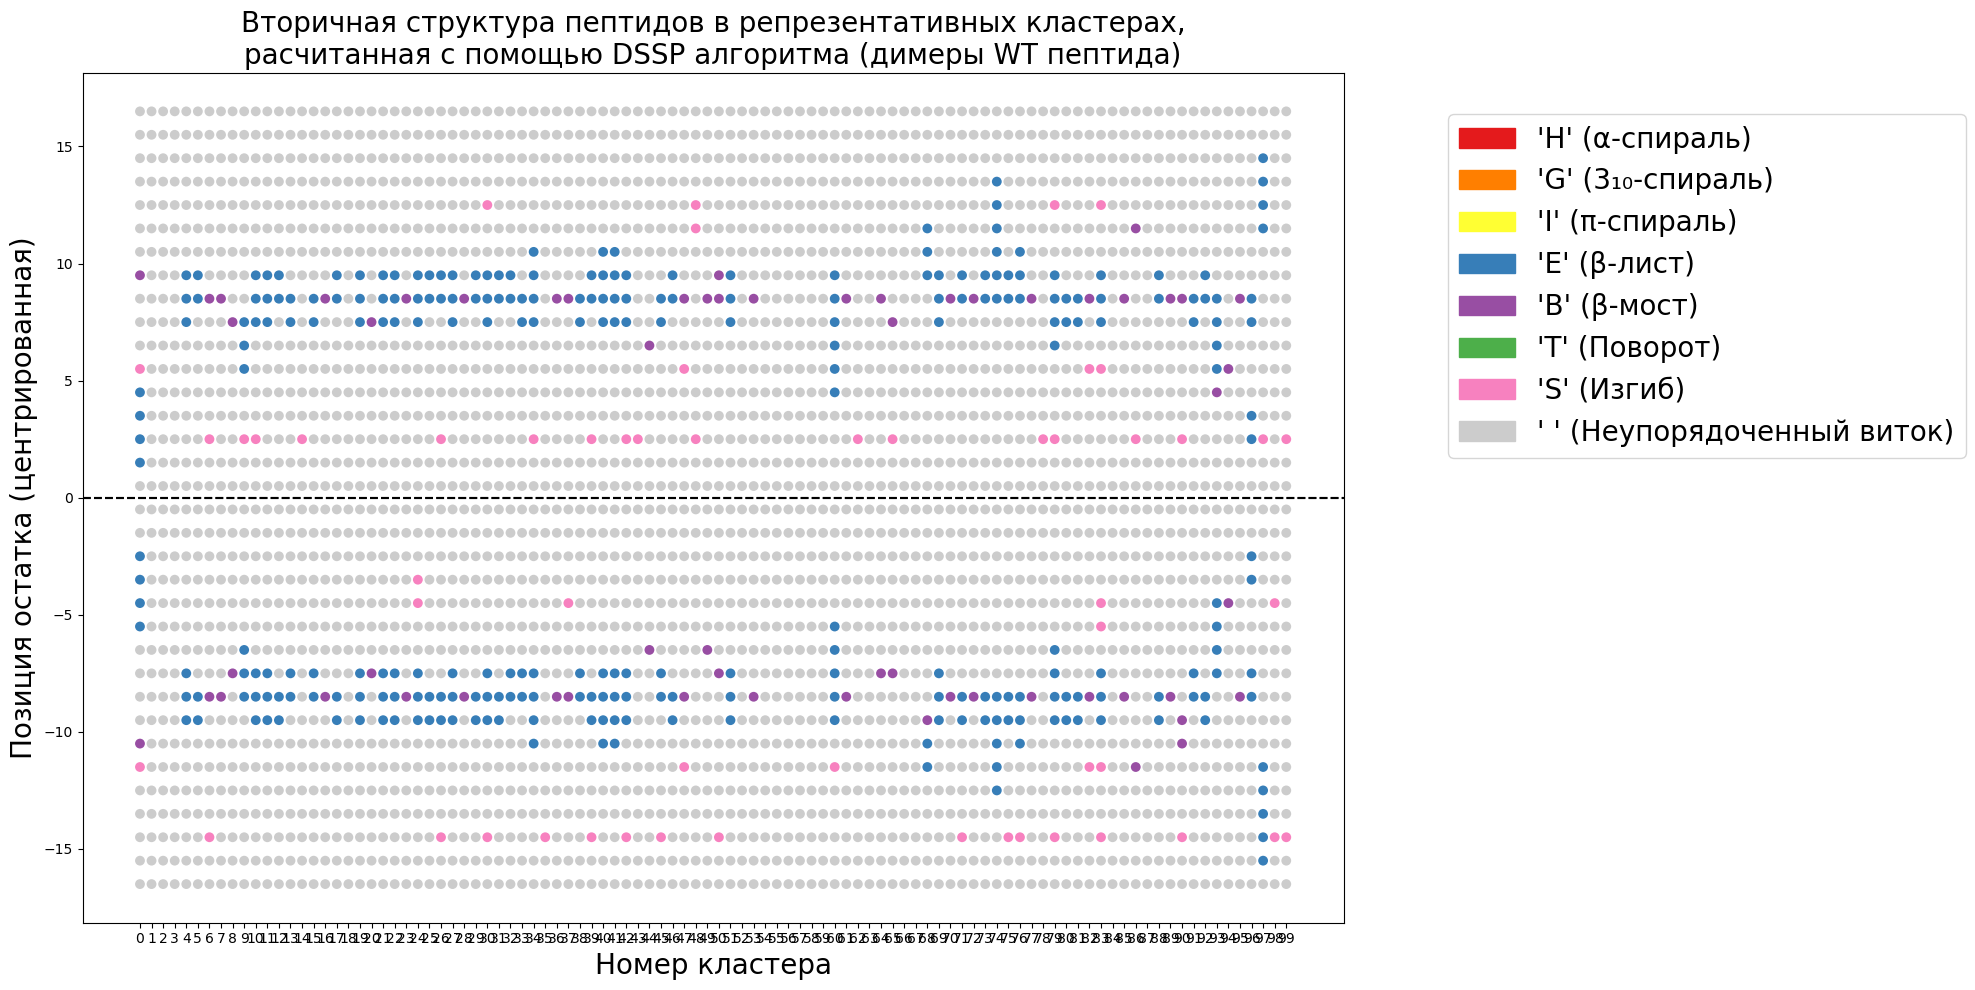

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_dssp_clusters(cluster_dssp, figsize=(20, 10), title="DSSP across clusters", peptide_length=17):
    """
    cluster_dssp : list of lists (or strings) of DSSP characters
                   e.g., [ ['E','E',' ','H',...], [' ',' ','E',...], ... ]
    """
    n_clusters = len(cluster_dssp)
    L = len(cluster_dssp[0])
    # Center residues around 0: position i -> i - (L-1)/2
    n_monomers = L // peptide_length
    y_positions = np.arange(L) - (L - 1) / 2
    # Color map for common DSSP codes
    cmap = {
        'H': '#e41a1c',   # alpha-helix (red)
        'G': '#ff7f00',   # 3-10 helix (orange)
        'I': '#ffff33',   # pi-helix (yellow)
        'E': '#377eb8',   # extended strand (blue)
        'B': '#984ea3',   # beta-bridge (purple)
        'T': '#4daf4a',   # turn (green)
        'S': '#f781bf',   # bend (pink)
        ' ': '#cccccc',   # coil / unstructured (light grey)
        '-': '#cccccc',   # alternative coil symbol
        '?': '#000000'    # unknown (black)
    }
    
    fig, ax = plt.subplots(figsize=figsize)
    
    for i, dssp_seq in enumerate(cluster_dssp):
        if isinstance(dssp_seq, str):
            dssp_seq = list(dssp_seq)
        for j, code in enumerate(dssp_seq):
            color = cmap.get(code, '#000000')
            ax.scatter(i, y_positions[j], color=color, s=50, edgecolors='none', alpha=1)
    for k in range(1, n_monomers):
        boundary_y = (peptide_length * k - 0.5) - (L - 1) / 2
        ax.axhline(boundary_y, color='black', linestyle='--', linewidth=1.5)

    
    ax.set_xlabel("Номер кластера", fontsize=20)
    ax.set_ylabel("Позиция остатка (центрированная)", fontsize=20)
    ax.set_title(title, fontsize=20)
    ax.set_xticks(range(n_clusters))
    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
    legend_patches = [mpatches.Patch(color=color, label=f"'{code}' ({name})")
                      for code, color, name in [
                          ('H', '#e41a1c', 'α-спираль'),
                          ('G', '#ff7f00', '3₁₀-спираль'),
                          ('I', '#ffff33', 'π-спираль'),
                          ('E', '#377eb8', 'β-лист'),
                          ('B', '#984ea3', 'β-мост'),
                          ('T', '#4daf4a', 'Поворот'),
                          ('S', '#f781bf', 'Изгиб'),
                          (' ', '#cccccc', 'Неупорядоченный виток'),]]
    ax.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=1.5, fontsize=20)
    plt.tight_layout()
    plt.savefig('2WT.jpg', dpi=900)
    plt.show()
plot_dssp_clusters(candidates, title="Вторичная структура пептидов в репрезентативных кластерах,\nрасчитанная с помощью DSSP алгоритма (димеры WT пептида)")

### iRMSD (multichains)

In [383]:
import os
import glob
import numpy as np
import mdtraj as md
from scipy.cluster.hierarchy import fcluster, linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm

models_dir = "./6MUT"          # folder with your PDB files (all must have the same chain count)
interface_cutoff = 0.8           # nm (8 Å) – heavy-atom distance to define interface
rmsd_cutoff = 0.8                # nm (3 Å) – iRMSD threshold for clustering


def get_interface_multichain(traj, cutoff):
    """
    Returns a set of (chain_index, residue_index) tuples for residues
    whose heavy atoms are within `cutoff` of heavy atoms in a different chain.
    """
    top = traj.topology
    xyz = traj.xyz[0]
    chains = list(top.chains)
    chain_ids = [ch.index for ch in chains]
    heavy = {}
    for cid in chain_ids:
        sel = top.select(f"chainid {cid} and not element H")
        if len(sel) > 0:
            heavy[cid] = sel

    interface = set()
    chain_list = list(heavy.keys())
    for a in range(len(chain_list)):
        for b in range(a+1, len(chain_list)):
            cidA, cidB = chain_list[a], chain_list[b]
            hA, hB = heavy[cidA], heavy[cidB]
            if len(hA) == 0 or len(hB) == 0:
                continue
            dists = np.linalg.norm(xyz[hA][:, None, :] - xyz[hB][None, :, :], axis=2)
            close = np.where(dists < cutoff)
            for i, j in zip(close[0], close[1]):
                resA = top.atom(hA[i]).residue.index
                resB = top.atom(hB[j]).residue.index
                interface.add((cidA, resA)) 
                interface.add((cidB, resB))
    return interface


In [384]:
pdb_files = sorted(glob.glob(os.path.join(models_dir, "*.pdb")))
n_models = len(pdb_files)

models = []                 # list of mdtraj.Trajectory
models_ca_maps = []         # list of dict: (chain_idx, res_idx) -> CA atom index
interface_sets = []         # list of set of (chain_idx, res_idx) tuples

for f in tqdm(pdb_files, desc="Precomputing models"):
    traj = md.load(f)
    models.append(traj)
    ca_map = {}
    for atom in traj.topology.atoms:
        if atom.name == 'CA':
            res = atom.residue
            key = (res.chain.index, res.index)
            ca_map[key] = atom.index
    models_ca_maps.append(ca_map)
    iface = get_interface_multichain(traj, interface_cutoff)
    interface_sets.append(iface)


irmsd_matrix = np.zeros((n_models, n_models))
try:
    loop_range = tqdm(range(n_models), desc="iRMSD matrix")
except ImportError:
    loop_range = range(n_models)

for i in loop_range:
    set_i = interface_sets[i]
    map_i = models_ca_maps[i]
    if not set_i:
        # model has no inter‑chain contacts – mark as distant to everything
        irmsd_matrix[i, :] = 999.0
        irmsd_matrix[:, i] = 999.0
        continue

    for j in range(i+1, n_models):
        set_j = interface_sets[j]
        map_j = models_ca_maps[j]
        if not set_j:
            irmsd_matrix[i, j] = 999.0
            irmsd_matrix[j, i] = 999.0
            continue

        common = set_i & set_j   # intersection of (chain,res) tuples
        if not common:
            irmsd_matrix[i, j] = 999.0
            irmsd_matrix[j, i] = 999.0
            continue
        common_sorted = sorted(common)
        ca_i = np.array([map_i[key] for key in common_sorted])
        ca_j = np.array([map_j[key] for key in common_sorted])

        if len(ca_i) == 0 or len(ca_i) != len(ca_j):
            irmsd_matrix[i, j] = 999.0
            irmsd_matrix[j, i] = 999.0
            continue
        models[j].superpose(models[i], atom_indices=ca_j, ref_atom_indices=ca_i)
        diff = models[j].xyz[0, ca_j, :] - models[i].xyz[0, ca_i, :]
        rmsd_val = np.sqrt(np.mean(np.sum(diff**2, axis=1)))
        irmsd_matrix[i, j] = rmsd_val
        irmsd_matrix[j, i] = rmsd_val

np.fill_diagonal(irmsd_matrix, 0)


valid_mask = np.array([len(s) > 0 for s in interface_sets])
valid_indices = np.where(valid_mask)[0]
rmsd_sub = irmsd_matrix[np.ix_(valid_indices, valid_indices)]
dist_vec = squareform(rmsd_sub)
linkage_matrix = linkage(dist_vec, method='average')
clusters_sub = fcluster(linkage_matrix, t=rmsd_cutoff, criterion='distance')

clusters_full = -1 * np.ones(n_models, dtype=int)
clusters_full[valid_indices] = clusters_sub

n_clusters = len(set(clusters_sub))
print(f"Clusters at {interface_cutoff} nm iRMSD: {n_clusters}")

cluster_groups = defaultdict(list)
for idx, c in enumerate(clusters_full):
    if c != -1:
        cluster_groups[c].append(idx)

for cid, idx_list in cluster_groups.items():
    if len(idx_list) == 1:
        rep_idx = idx_list[0]
    else:
        # choose the model with smallest mean iRMSD to others in the cluster
        sub = irmsd_matrix[np.ix_(idx_list, idx_list)]
        mean_dist = np.mean(sub, axis=1)
        rep_idx = idx_list[np.argmin(mean_dist)]
    out_name = f"cluster_{cid}_iRMSD_rep.pdb"
    models[rep_idx].save(out_name)
    print(f"Cluster {cid} with {len(idx_list)} models as {out_name}")

iRMSD matrix: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [00:08<00:00, 28.73it/s]


Clusters at 0.8 nm iRMSD: 101
Cluster 9 with 59 models as cluster_9_iRMSD_rep.pdb
Cluster 7 with 3 models as cluster_7_iRMSD_rep.pdb
Cluster 15 with 22 models as cluster_15_iRMSD_rep.pdb
Cluster 51 with 1 models as cluster_51_iRMSD_rep.pdb
Cluster 5 with 1 models as cluster_5_iRMSD_rep.pdb
Cluster 11 with 5 models as cluster_11_iRMSD_rep.pdb
Cluster 14 with 2 models as cluster_14_iRMSD_rep.pdb
Cluster 12 with 1 models as cluster_12_iRMSD_rep.pdb
Cluster 47 with 2 models as cluster_47_iRMSD_rep.pdb
Cluster 43 with 1 models as cluster_43_iRMSD_rep.pdb
Cluster 38 with 4 models as cluster_38_iRMSD_rep.pdb
Cluster 48 with 3 models as cluster_48_iRMSD_rep.pdb
Cluster 99 with 4 models as cluster_99_iRMSD_rep.pdb
Cluster 27 with 1 models as cluster_27_iRMSD_rep.pdb
Cluster 86 with 3 models as cluster_86_iRMSD_rep.pdb
Cluster 95 with 2 models as cluster_95_iRMSD_rep.pdb
Cluster 33 with 2 models as cluster_33_iRMSD_rep.pdb
Cluster 59 with 3 models as cluster_59_iRMSD_rep.pdb
Cluster 70 with 1 mo

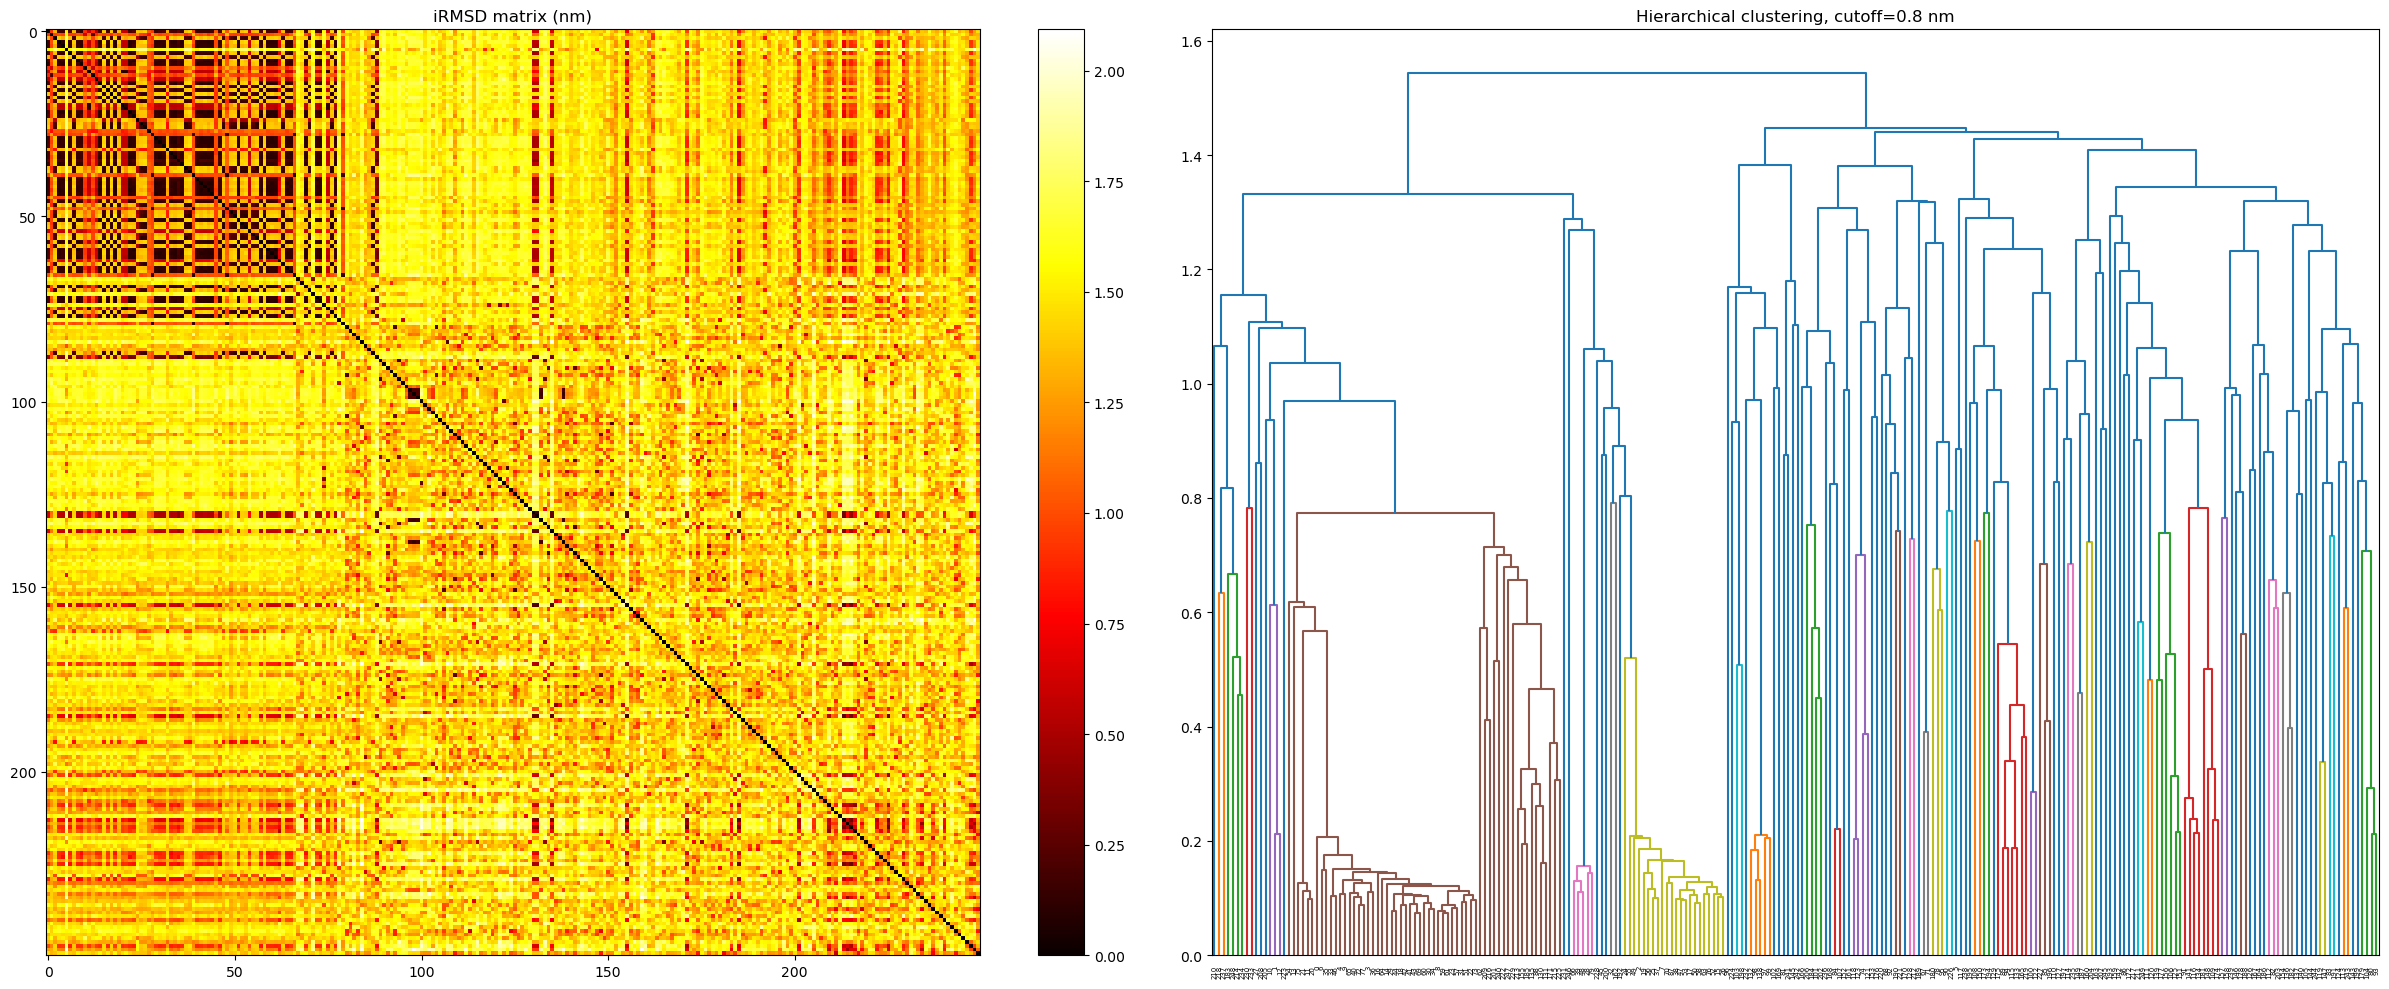

In [385]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))
im = ax1.imshow(irmsd_matrix, cmap='hot', aspect='auto')
ax1.set_title("iRMSD matrix (nm)")
plt.colorbar(im, ax=ax1)

dendrogram(linkage_matrix, ax=ax2, color_threshold=rmsd_cutoff,
           labels=[str(i) for i in valid_indices])
ax2.set_title(f"Hierarchical clustering, cutoff={rmsd_cutoff} nm")
plt.tight_layout()
plt.savefig("irmsd_clustering_6MUT.png", dpi=600)
plt.show()

In [386]:
import os
import glob
import mdtraj as md
import numpy as np


rep_dir = "."
rep_files = sorted(glob.glob(os.path.join(rep_dir, "cluster_*_iRMSD_rep.pdb")))


candidates = []

for rep_file in rep_files:
    traj = md.load(rep_file)
    top = traj.topology
    chains = list(top.chains)
    ss = md.compute_dssp(traj, simplified=False)[0]
    print(ss)
    candidates.append(ss)

[' ' ' ' ' ' ' ' ' ' ' ' ' ' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' 'B' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' ' ' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' 'B' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' 'B'
 ' ' ' ' ' ' ' ' ' ' 'B' ' ' 'B' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' 'B' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' 'E' 'E' 'E' 'E' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' 'E' 'E' 'E' 'E' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' '

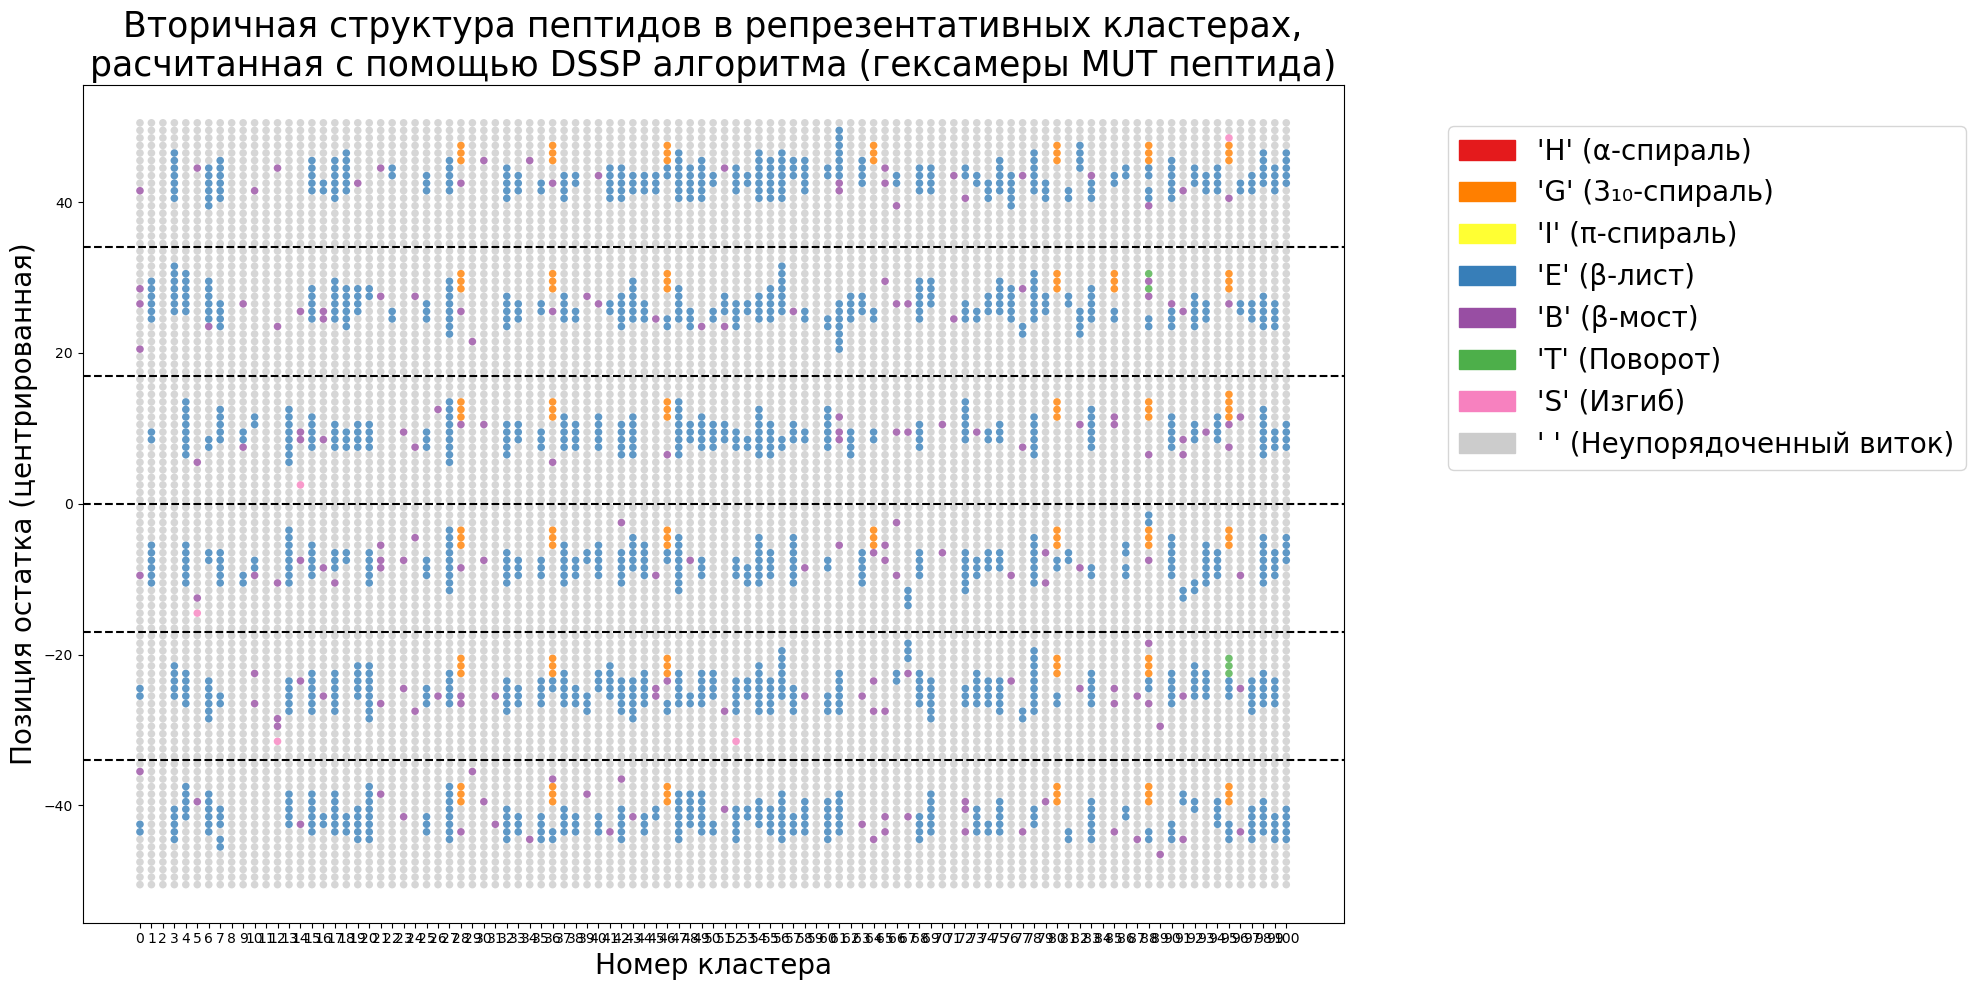

In [388]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_dssp_clusters(cluster_dssp, figsize=(20, 10), title="DSSP across clusters"):
    """
    cluster_dssp : list of lists (or strings) of DSSP characters
                   e.g., [ ['E','E',' ','H',...], [' ',' ','E',...], ... ]
    """
    n_clusters = len(cluster_dssp)
    L = len(cluster_dssp[0])
    # Center residues around 0: position i -> i - (L-1)/2
    y_positions = np.arange(L) - (L - 1) / 2

    # Color map for common DSSP codes
    cmap = {
        'H': '#e41a1c',   # alpha-helix (red)
        'G': '#ff7f00',   # 3-10 helix (orange)
        'I': '#ffff33',   # pi-helix (yellow)
        'E': '#377eb8',   # extended strand (blue)
        'B': '#984ea3',   # beta-bridge (purple)
        'T': '#4daf4a',   # turn (green)
        'S': '#f781bf',   # bend (pink)
        ' ': '#cccccc',   # coil / unstructured (light grey)
        '-': '#cccccc',   # alternative coil symbol
        '?': '#000000'    # unknown (black)
    }
    
    fig, ax = plt.subplots(figsize=figsize)
    
    for i, dssp_seq in enumerate(cluster_dssp):
        if isinstance(dssp_seq, str):
            dssp_seq = list(dssp_seq)
        for j, code in enumerate(dssp_seq):
            color = cmap.get(code, '#000000')
            ax.scatter(i, y_positions[j], color=color, s=30, edgecolors='none', alpha=0.8)
    
    ax.set_xlabel("Номер кластера", fontsize=20)
    ax.set_ylabel("Позиция остатка (центрированная)", fontsize=20)
    ax.set_title(title, fontsize=25)
    ax.set_xticks(range(n_clusters))
    ax.axhline(17, color='black', linewidth=1.5, linestyle='--')
    ax.axhline(-17, color='black', linewidth=1.5, linestyle='--')
    ax.axhline(34, color='black', linewidth=1.5, linestyle='--')
    ax.axhline(-34, color='black', linewidth=1.5, linestyle='--')
    ax.axhline(-0, color='black', linewidth=1.5, linestyle='--')
    legend_patches = [mpatches.Patch(color=color, label=f"'{code}' ({name})")
                      for code, color, name in [
                          ('H', '#e41a1c', 'α-спираль'),
                          ('G', '#ff7f00', '3₁₀-спираль'),
                          ('I', '#ffff33', 'π-спираль'),
                          ('E', '#377eb8', 'β-лист'),
                          ('B', '#984ea3', 'β-мост'),
                          ('T', '#4daf4a', 'Поворот'),
                          ('S', '#f781bf', 'Изгиб'),
                          (' ', '#cccccc', 'Неупорядоченный виток'),]]
    ax.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=1.5, fontsize=20)
    plt.tight_layout()
    plt.savefig('6MUT.jpg', dpi=900)
    plt.show()
plot_dssp_clusters(candidates, title="Вторичная структура пептидов в репрезентативных кластерах,\nрасчитанная с помощью DSSP алгоритма (гексамеры MUT пептида)")

### Filtration algorithm

In [390]:
def select_by_dssp_composition(dssp_list, peptide_length=17,
                               rules=None, verbose=True):
    """
    Отбирает кластеры по процентному составу кодов DSSP во всей последовательности.

    Parameters
    ----------
    dssp_list : list of str or list of list of char
        Список DSSP-строк для каждого кандидата.
    peptide_length : int
        Длина одного мономера (по умолчанию 17).
    rules : dict, optional
        Словарь правил: ключ – код DSSP (например 'E', 'H', ' ', ...),
        значение – кортеж (min_percent, max_percent) или одиночное число min_percent (тогда max = 100).
        Пример: {'E': (20, 60), 'H': (0, 5), ' ': (0, 80)}
        Если rules = None, возвращаются все индексы.
    verbose : bool
        Печатать ли отчёт.

    Returns
    -------
    selected_indices : list of int
        Индексы в исходном dssp_list, удовлетворяющие условиям.
    """

    if rules is None:
        return list(range(len(dssp_list)))

    # Приведём правила к единому виду (min, max) в процентах
    parsed_rules = {}
    for code, val in rules.items():
        if isinstance(val, (int, float)):
            parsed_rules[code] = (val, 100.0)  # только нижняя граница
        else:
            parsed_rules[code] = (float(val[0]), float(val[1]))

    selected = []
    for idx, dssp_seq in enumerate(dssp_list):
        if isinstance(dssp_seq, str):
            dssp_seq = list(dssp_seq)

        L = len(dssp_seq)
        # Подсчитываем частоты кодов в процентах
        unique, counts = np.unique(dssp_seq, return_counts=True)
        percent = dict(zip(unique, 100.0 * counts / L))

        ok = True
        for code, (lo, hi) in parsed_rules.items():
            actual = percent.get(code, 0.0)
            if not (lo <= actual <= hi):
                ok = False
                break
        if ok:
            selected.append(idx)

    if verbose:
        print(f"Отобрано {len(selected)} из {len(dssp_list)} кластеров "
              f"по правилам: {parsed_rules}")
    return selected


rules = {'E': (15, 60), 'B': (0, 20)}
idx = select_by_dssp_composition(candidates, peptide_length=17, rules=rules)
filtered_candidates = [candidates[i] for i in idx]

Отобрано 47 из 101 кластеров по правилам: {'E': (15.0, 60.0), 'B': (0.0, 20.0)}


In [391]:
rep_files = sorted(glob.glob("cluster_*_iRMSD_rep.pdb"))
selected_files = [rep_files[i] for i in idx]
print("Оставить следующие PDB-файлы (репрезентанты кластеров):")
for f in selected_files:
    print(f)
import re
cluster_numbers = []
for f in selected_files:
    match = re.search(r'cluster_(\d+)', f)
    if match:
        cluster_numbers.append(int(match.group(1)))
    else:
        print(f"Не удалось извлечь номер из {f}")

Оставить следующие PDB-файлы (репрезентанты кластеров):
cluster_11_iRMSD_rep.pdb
cluster_12_iRMSD_rep.pdb
cluster_14_iRMSD_rep.pdb
cluster_15_iRMSD_rep.pdb
cluster_20_iRMSD_rep.pdb
cluster_22_iRMSD_rep.pdb
cluster_24_iRMSD_rep.pdb
cluster_25_iRMSD_rep.pdb
cluster_26_iRMSD_rep.pdb
cluster_27_iRMSD_rep.pdb
cluster_31_iRMSD_rep.pdb
cluster_33_iRMSD_rep.pdb
cluster_38_iRMSD_rep.pdb
cluster_39_iRMSD_rep.pdb
cluster_40_iRMSD_rep.pdb
cluster_42_iRMSD_rep.pdb
cluster_43_iRMSD_rep.pdb
cluster_45_iRMSD_rep.pdb
cluster_47_iRMSD_rep.pdb
cluster_48_iRMSD_rep.pdb
cluster_49_iRMSD_rep.pdb
cluster_51_iRMSD_rep.pdb
cluster_52_iRMSD_rep.pdb
cluster_53_iRMSD_rep.pdb
cluster_56_iRMSD_rep.pdb
cluster_58_iRMSD_rep.pdb
cluster_59_iRMSD_rep.pdb
cluster_5_iRMSD_rep.pdb
cluster_60_iRMSD_rep.pdb
cluster_63_iRMSD_rep.pdb
cluster_64_iRMSD_rep.pdb
cluster_70_iRMSD_rep.pdb
cluster_71_iRMSD_rep.pdb
cluster_74_iRMSD_rep.pdb
cluster_75_iRMSD_rep.pdb
cluster_76_iRMSD_rep.pdb
cluster_77_iRMSD_rep.pdb
cluster_7_iRMSD_rep.

In [392]:
print("Номера кластеров:", sorted(cluster_numbers))

Номера кластеров: [5, 7, 9, 11, 12, 14, 15, 20, 22, 24, 25, 26, 27, 31, 33, 38, 39, 40, 42, 43, 45, 47, 48, 49, 51, 52, 53, 56, 58, 59, 60, 63, 64, 70, 71, 74, 75, 76, 77, 84, 90, 92, 93, 94, 97, 98, 99]


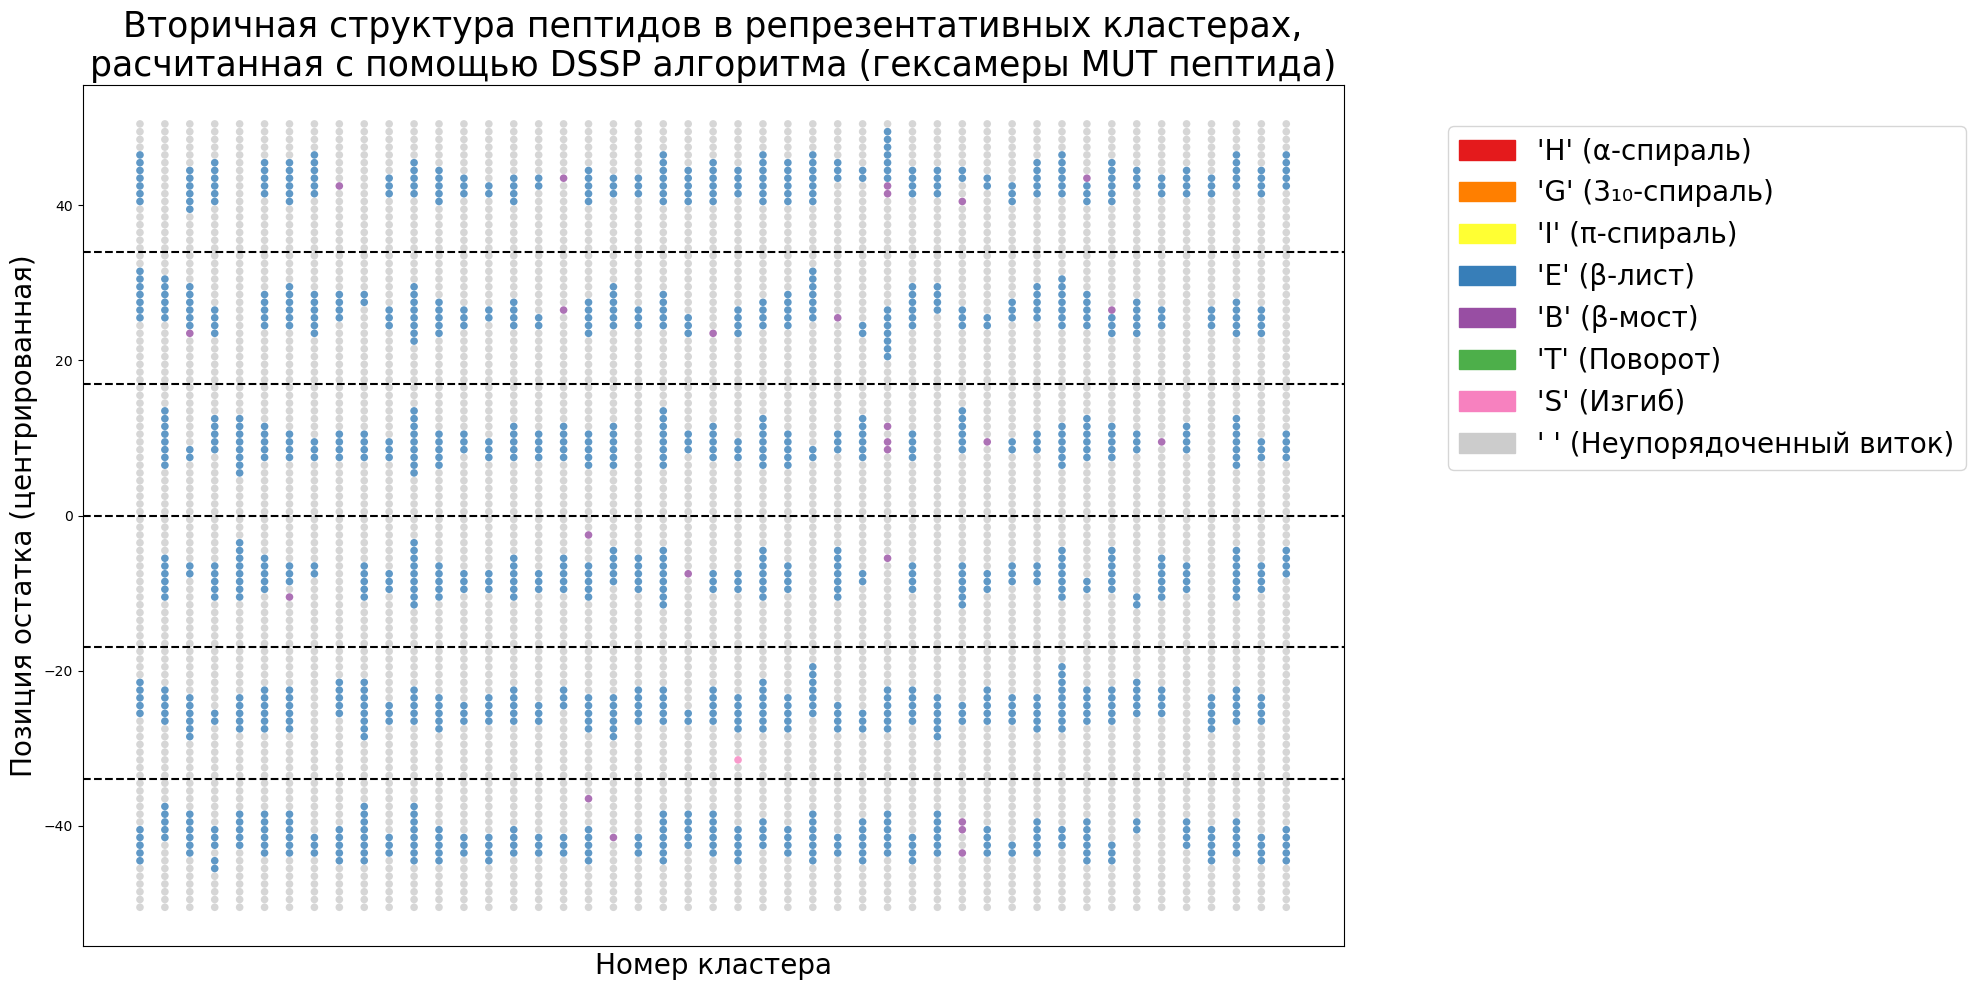

In [393]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_dssp_clusters(cluster_dssp, figsize=(20, 10), title="DSSP across clusters"):
    """
    cluster_dssp : list of lists (or strings) of DSSP characters
                   e.g., [ ['E','E',' ','H',...], [' ',' ','E',...], ... ]
    """
    n_clusters = len(cluster_dssp)
    L = len(cluster_dssp[0])
    # Center residues around 0: position i -> i - (L-1)/2
    y_positions = np.arange(L) - (L - 1) / 2

    # Color map for common DSSP codes
    cmap = {
        'H': '#e41a1c',   # alpha-helix (red)
        'G': '#ff7f00',   # 3-10 helix (orange)
        'I': '#ffff33',   # pi-helix (yellow)
        'E': '#377eb8',   # extended strand (blue)
        'B': '#984ea3',   # beta-bridge (purple)
        'T': '#4daf4a',   # turn (green)
        'S': '#f781bf',   # bend (pink)
        ' ': '#cccccc',   # coil / unstructured (light grey)
        '-': '#cccccc',   # alternative coil symbol
        '?': '#000000'    # unknown (black)
    }
    
    fig, ax = plt.subplots(figsize=figsize)
    
    for i, dssp_seq in enumerate(cluster_dssp):
        if isinstance(dssp_seq, str):
            dssp_seq = list(dssp_seq)
        for j, code in enumerate(dssp_seq):
            color = cmap.get(code, '#000000')
            ax.scatter(i, y_positions[j], color=color, s=30, edgecolors='none', alpha=0.8)
    
    ax.set_xlabel("Номер кластера", fontsize=20)
    ax.set_ylabel("Позиция остатка (центрированная)", fontsize=20)
    ax.set_title(title, fontsize=25)
    ax.set_xticks(range(n_clusters, 1))
    ax.axhline(17, color='black', linewidth=1.5, linestyle='--')
    ax.axhline(-17, color='black', linewidth=1.5, linestyle='--')
    ax.axhline(34, color='black', linewidth=1.5, linestyle='--')
    ax.axhline(-34, color='black', linewidth=1.5, linestyle='--')
    ax.axhline(-0, color='black', linewidth=1.5, linestyle='--')
    legend_patches = [mpatches.Patch(color=color, label=f"'{code}' ({name})")
                      for code, color, name in [
                          ('H', '#e41a1c', 'α-спираль'),
                          ('G', '#ff7f00', '3₁₀-спираль'),
                          ('I', '#ffff33', 'π-спираль'),
                          ('E', '#377eb8', 'β-лист'),
                          ('B', '#984ea3', 'β-мост'),
                          ('T', '#4daf4a', 'Поворот'),
                          ('S', '#f781bf', 'Изгиб'),
                          (' ', '#cccccc', 'Неупорядоченный виток'),]]
    ax.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=1.5, fontsize=20)
    plt.tight_layout()
    plt.savefig('6MUT_FILTERED.jpg', dpi=900)
    plt.show()
plot_dssp_clusters(filtered_candidates, title="Вторичная структура пептидов в репрезентативных кластерах,\nрасчитанная с помощью DSSP алгоритма (гексамеры MUT пептида)")

### Post-relaxation DSSP & Filtering

In [394]:
import os
import glob
import mdtraj as md
import numpy as np


rep_dir = "."
rep_files = sorted(glob.glob("relaxed_cluster_*_iRMSD_rep.pdb"))
relaxed_candidates = []

for rep_file in rep_files:
    traj = md.load(rep_file)
    top = traj.topology
    chains = list(top.chains)
    ss = md.compute_dssp(traj, simplified=False)[0]
    print(ss)
    relaxed_candidates.append(ss)

[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' ' ' 'E' 'E' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' 'E' 'E' 'E' 'E' ' ' ' ' ' ' ' ']
[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' 'B' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' 'B' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' 'E' 'E' 'E' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' 'E' 'E' 'E' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' ' ' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' ' ' ' ' ' ' ' ' ' ' 'E' 'E' 'E' 'E' 'E' 'E' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' 'E' 'E' 'E' 'E' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' '

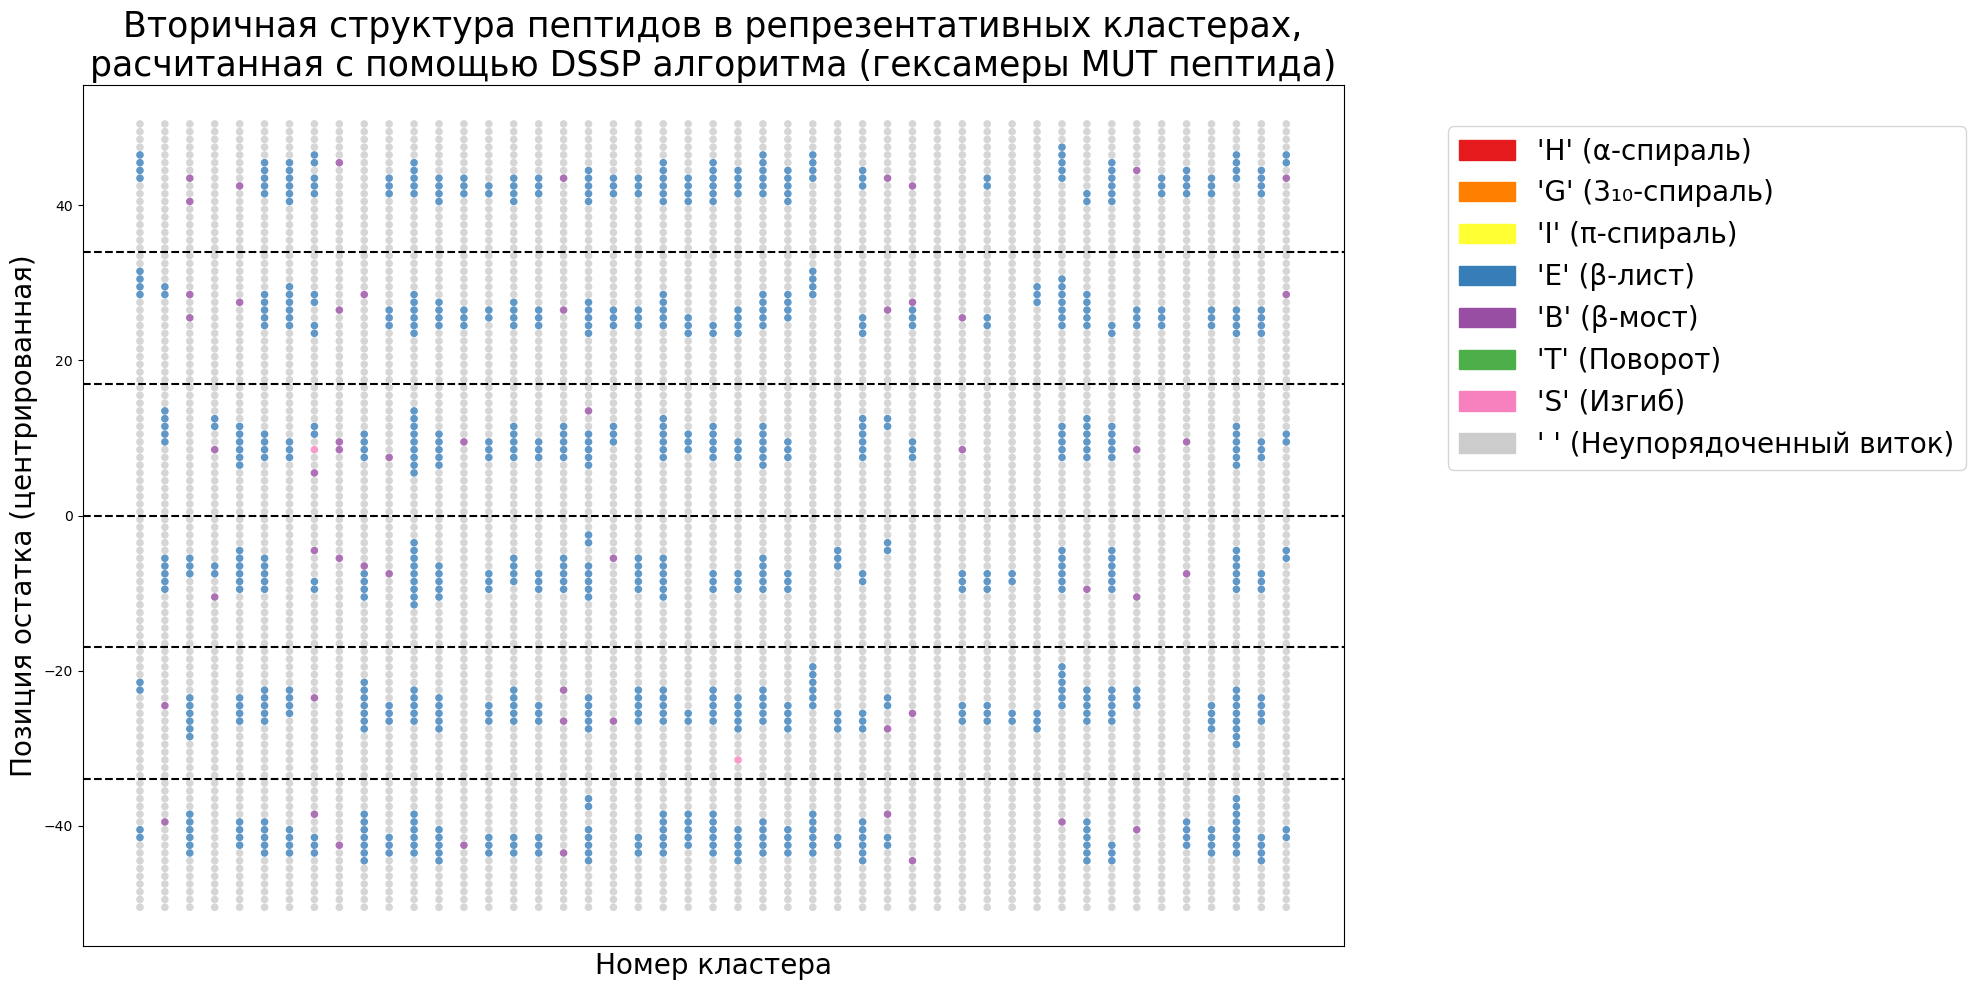

In [395]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_dssp_clusters(cluster_dssp, figsize=(20, 10), title="DSSP across clusters"):
    """
    cluster_dssp : list of lists (or strings) of DSSP characters
                   e.g., [ ['E','E',' ','H',...], [' ',' ','E',...], ... ]
    """
    n_clusters = len(cluster_dssp)
    L = len(cluster_dssp[0])
    # Center residues around 0: position i -> i - (L-1)/2
    y_positions = np.arange(L) - (L - 1) / 2

    # Color map for common DSSP codes
    cmap = {
        'H': '#e41a1c',   # alpha-helix (red)
        'G': '#ff7f00',   # 3-10 helix (orange)
        'I': '#ffff33',   # pi-helix (yellow)
        'E': '#377eb8',   # extended strand (blue)
        'B': '#984ea3',   # beta-bridge (purple)
        'T': '#4daf4a',   # turn (green)
        'S': '#f781bf',   # bend (pink)
        ' ': '#cccccc',   # coil / unstructured (light grey)
        '-': '#cccccc',   # alternative coil symbol
        '?': '#000000'    # unknown (black)
    }
    
    fig, ax = plt.subplots(figsize=figsize)
    
    for i, dssp_seq in enumerate(cluster_dssp):
        if isinstance(dssp_seq, str):
            dssp_seq = list(dssp_seq)
        for j, code in enumerate(dssp_seq):
            color = cmap.get(code, '#000000')
            ax.scatter(i, y_positions[j], color=color, s=30, edgecolors='none', alpha=0.8)
    
    ax.set_xlabel("Номер кластера", fontsize=20)
    ax.set_ylabel("Позиция остатка (центрированная)", fontsize=20)
    ax.set_title(title, fontsize=25)
    ax.set_xticks(range(n_clusters, 1))
    ax.axhline(17, color='black', linewidth=1.5, linestyle='--')
    ax.axhline(-17, color='black', linewidth=1.5, linestyle='--')
    ax.axhline(34, color='black', linewidth=1.5, linestyle='--')
    ax.axhline(-34, color='black', linewidth=1.5, linestyle='--')
    ax.axhline(-0, color='black', linewidth=1.5, linestyle='--')
    legend_patches = [mpatches.Patch(color=color, label=f"'{code}' ({name})")
                      for code, color, name in [
                          ('H', '#e41a1c', 'α-спираль'),
                          ('G', '#ff7f00', '3₁₀-спираль'),
                          ('I', '#ffff33', 'π-спираль'),
                          ('E', '#377eb8', 'β-лист'),
                          ('B', '#984ea3', 'β-мост'),
                          ('T', '#4daf4a', 'Поворот'),
                          ('S', '#f781bf', 'Изгиб'),
                          (' ', '#cccccc', 'Неупорядоченный виток'),]]
    ax.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=1.5, fontsize=20)
    plt.tight_layout()
    plt.savefig('6MUT_RELAXED.jpg', dpi=900)
    plt.show()
plot_dssp_clusters(relaxed_candidates, title="Вторичная структура пептидов в репрезентативных кластерах,\nрасчитанная с помощью DSSP алгоритма (гексамеры MUT пептида)")

In [396]:
def select_by_dssp_composition(dssp_list, peptide_length=17,
                               rules=None, verbose=True):
    """
    Отбирает кластеры по процентному составу кодов DSSP во всей последовательности.

    Parameters
    ----------
    dssp_list : list of str or list of list of char
        Список DSSP-строк для каждого кандидата.
    peptide_length : int
        Длина одного мономера (по умолчанию 17).
    rules : dict, optional
        Словарь правил: ключ – код DSSP (например 'E', 'H', ' ', ...),
        значение – кортеж (min_percent, max_percent) или одиночное число min_percent (тогда max = 100).
        Пример: {'E': (20, 60), 'H': (0, 5), ' ': (0, 80)}
        Если rules = None, возвращаются все индексы.
    verbose : bool
        Печатать ли отчёт.

    Returns
    -------
    selected_indices : list of int
        Индексы в исходном dssp_list, удовлетворяющие условиям.
    """

    if rules is None:
        return list(range(len(dssp_list)))

    # Приведём правила к единому виду (min, max) в процентах
    parsed_rules = {}
    for code, val in rules.items():
        if isinstance(val, (int, float)):
            parsed_rules[code] = (val, 100.0)  # только нижняя граница
        else:
            parsed_rules[code] = (float(val[0]), float(val[1]))

    selected = []
    for idx, dssp_seq in enumerate(dssp_list):
        if isinstance(dssp_seq, str):
            dssp_seq = list(dssp_seq)

        L = len(dssp_seq)
        # Подсчитываем частоты кодов в процентах
        unique, counts = np.unique(dssp_seq, return_counts=True)
        percent = dict(zip(unique, 100.0 * counts / L))

        ok = True
        for code, (lo, hi) in parsed_rules.items():
            actual = percent.get(code, 0.0)
            if not (lo <= actual <= hi):
                ok = False
                break
        if ok:
            selected.append(idx)

    if verbose:
        print(f"Отобрано {len(selected)} из {len(dssp_list)} кластеров "
              f"по правилам: {parsed_rules}")
    return selected


rules = {'E': (10, 60), 'B': (0, 20)}
idx = select_by_dssp_composition(relaxed_candidates, peptide_length=17, rules=rules)
filtered_relaxed_candidates = [candidates[i] for i in idx]

Отобрано 30 из 47 кластеров по правилам: {'E': (10.0, 60.0), 'B': (0.0, 20.0)}


In [397]:
rep_files = sorted(glob.glob("relaxed_cluster_*_iRMSD_rep.pdb"))
relaxed_selected_files = [rep_files[i] for i in idx]
print("Оставить следующие PDB-файлы (репрезентанты кластеров):")
for f in relaxed_selected_files:
    print(f)
import re
cluster_numbers = []
for f in relaxed_selected_files:
    match = re.search(r'relaxed_cluster_(\d+)', f)
    if match:
        cluster_numbers.append(int(match.group(1)))
print(sorted(cluster_numbers))

Оставить следующие PDB-файлы (репрезентанты кластеров):
relaxed_cluster_11_iRMSD_rep.pdb
relaxed_cluster_12_iRMSD_rep.pdb
relaxed_cluster_14_iRMSD_rep.pdb
relaxed_cluster_20_iRMSD_rep.pdb
relaxed_cluster_22_iRMSD_rep.pdb
relaxed_cluster_24_iRMSD_rep.pdb
relaxed_cluster_25_iRMSD_rep.pdb
relaxed_cluster_27_iRMSD_rep.pdb
relaxed_cluster_31_iRMSD_rep.pdb
relaxed_cluster_33_iRMSD_rep.pdb
relaxed_cluster_38_iRMSD_rep.pdb
relaxed_cluster_40_iRMSD_rep.pdb
relaxed_cluster_42_iRMSD_rep.pdb
relaxed_cluster_43_iRMSD_rep.pdb
relaxed_cluster_47_iRMSD_rep.pdb
relaxed_cluster_49_iRMSD_rep.pdb
relaxed_cluster_51_iRMSD_rep.pdb
relaxed_cluster_52_iRMSD_rep.pdb
relaxed_cluster_53_iRMSD_rep.pdb
relaxed_cluster_56_iRMSD_rep.pdb
relaxed_cluster_58_iRMSD_rep.pdb
relaxed_cluster_59_iRMSD_rep.pdb
relaxed_cluster_5_iRMSD_rep.pdb
relaxed_cluster_63_iRMSD_rep.pdb
relaxed_cluster_7_iRMSD_rep.pdb
relaxed_cluster_84_iRMSD_rep.pdb
relaxed_cluster_90_iRMSD_rep.pdb
relaxed_cluster_97_iRMSD_rep.pdb
relaxed_cluster_98_iRM